In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


trainのことをデータフレームという。

In [2]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

print("train:", train.shape)
print("test:", test.shape)

train: (891, 12)
test: (418, 11)


In [3]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## カテゴリ列、数値列、その他（前処理が必要そう）に分類する
今回の場合、
1. カテゴリ列：Pclass,Sex,SibSp,Embarked,Parch
2. 数値列：Age,Fare
3. その他：Name,Ticket,Cabin

Text(0.5, 1.0, 'Age')

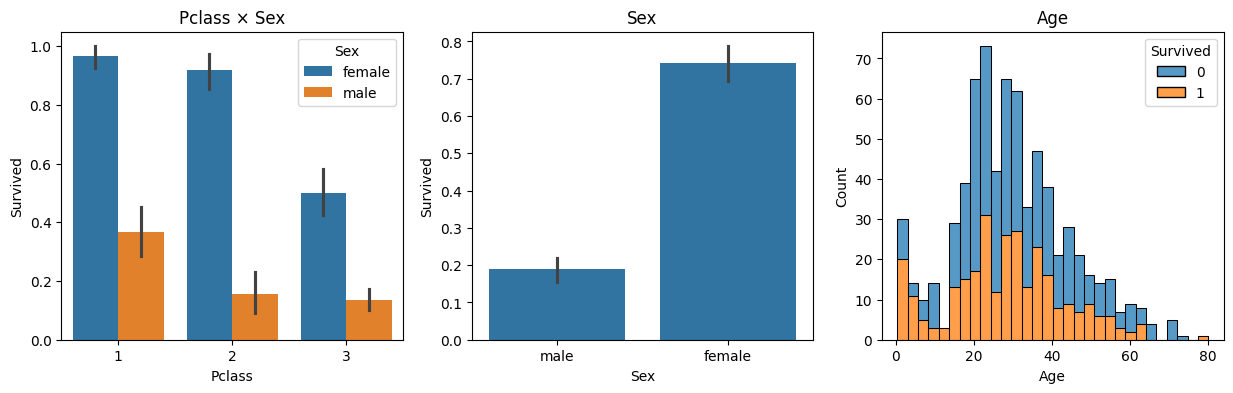

In [5]:
# いろいろ試してみる。
# グラフ描画領域確保
fig, axes = plt.subplots(1,3,figsize=(15,4))

# Pclass × Sexのグラフ描画
sns.barplot(data=train,x='Pclass',y='Survived',hue='Sex',ax=axes[0])
axes[0].set_title('Pclass × Sex')

# SexとSurvivedのグラフ描画
sns.barplot(data=train,x='Sex',y='Survived',ax=axes[1])
axes[1].set_title('Sex')

# Ageのグラフ描画
sns.histplot(data=train, x='Age', hue='Survived', multiple='stack', bins=30, ax=axes[2])
axes[2].set_title('Age')

## forループで一気に可視化してみる

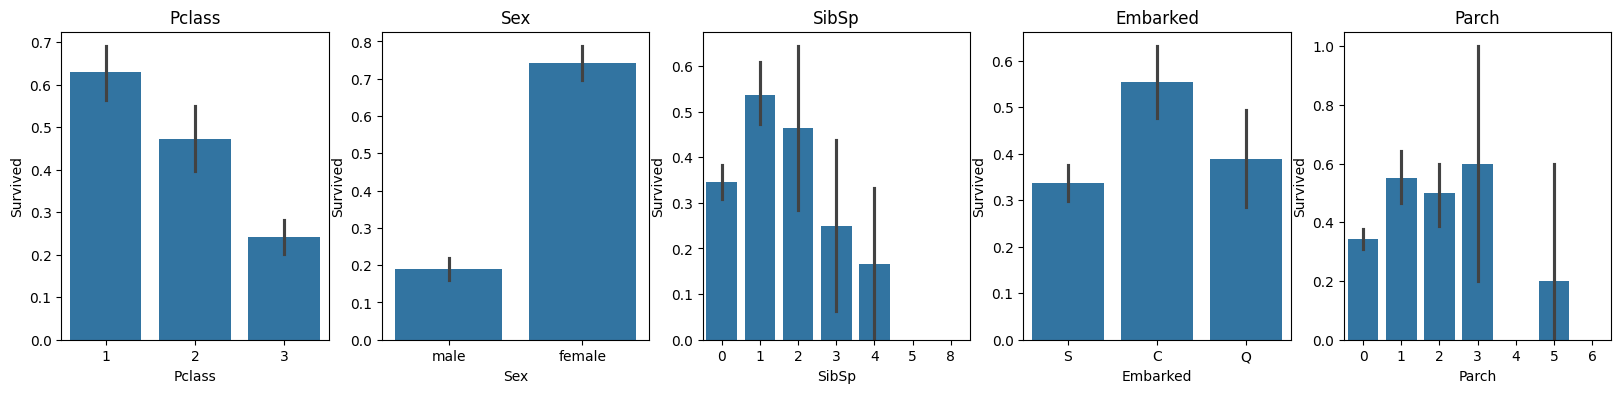

In [6]:
cat_cals = ['Pclass','Sex','SibSp','Embarked','Parch']

fig,axes = plt.subplots(1,len(cat_cals),figsize=(20,4))

# カテゴリ列のグラフ描画（棒グラフ）
for i, col in enumerate(cat_cals):
    sns.barplot(data=train, x=col, y='Survived', ax=axes[i])
    axes[i].set_title(col)
plt.show()

### カテゴリ列と生存率を見て気づいたこと

1. PclassとSexが強い説明変数
2. SibSpとParchを組み合わせた家族の人数は強そう

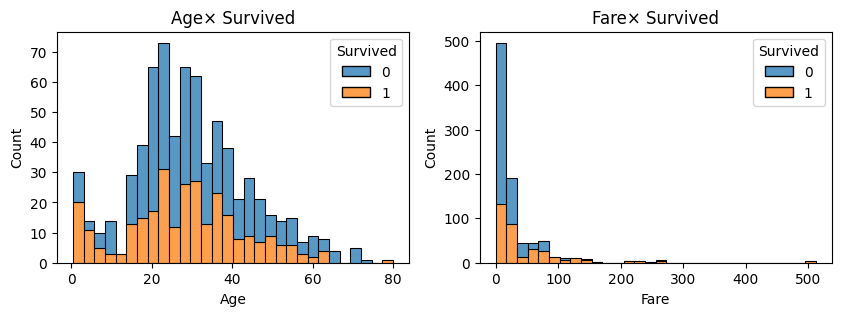

In [7]:
# 数値列のグラフ描画（ヒストグラム）
num_cals = ['Age','Fare']

fig,axes = plt.subplots(1,len(num_cals),figsize=(10,3))

for i, col in enumerate(num_cals):
    sns.histplot(data=train,x=col,hue='Survived',multiple='stack',bins=30,ax=axes[i])
    axes[i].set_title(col + '× Survived')

## 数値列と生存率の組み合わせで気づいたこと

### 1. 子供の生存率は高め
### 2. 高い賃料を支払ってる人生存率高め

## 気づいたことを基にいろいろ試してみる。

### 1. 家族人数（SubSpとParchを足して新しい列を作成）
### 2. Embarkedの差はPclassのせい？
### 3. Fareの高さはPclassと同じ意味？
### 4. 子供の生存率は高め（ただ小さすぎる(0-2)と生存率が少し高まる。）、ちょうど20代あたりは生存率低い

<Axes: xlabel='FamilySize', ylabel='Survived'>

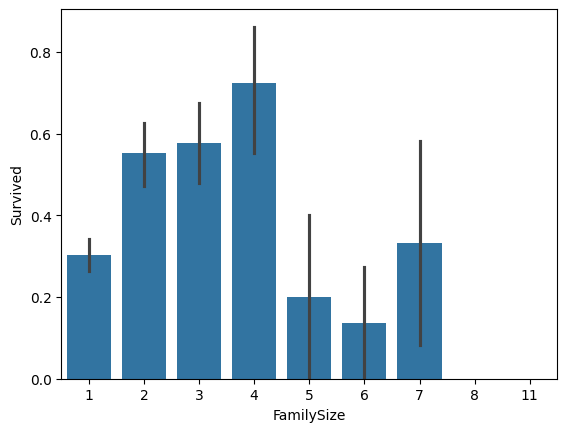

In [8]:
# 1から検証
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
sns.barplot(data=train, x='FamilySize', y='Survived')

## ここから気づくこと

### やはり、親族は多すぎず少なすぎずが生存率高め。→特徴量採用

<Axes: xlabel='Embarked', ylabel='Survived'>

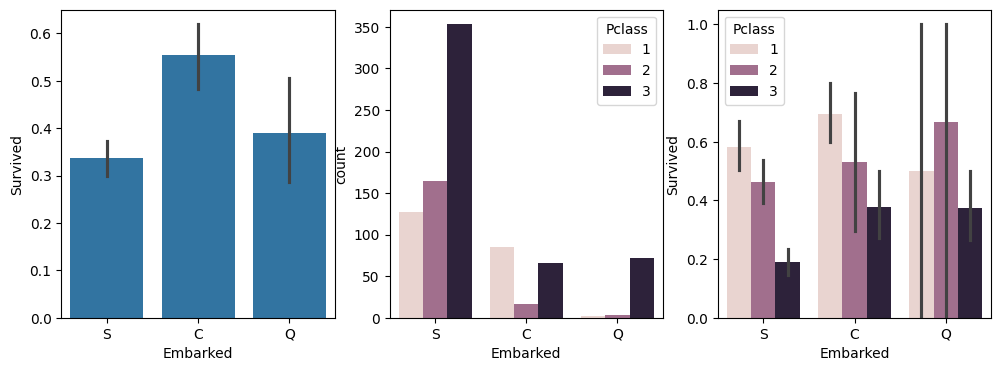

In [9]:
# 2の検証
fig,axes = plt.subplots(1,3,figsize=(12,4))

# 港ごとの生存率
sns.barplot(data=train, x='Embarked', y='Survived', ax=axes[0])

# 港ごとのクラス分布（C港には高いクラスが多い？）
sns.countplot(data=train, x='Embarked', hue='Pclass', ax=axes[1])

# 港とクラスを合わせて生存率を見る
sns.barplot(data=train, x='Embarked', y='Survived', hue='Pclass',ax=axes[2])

## ここから気づいたこと

### 1. C港にはクラス1の人が多い。
### 2. Q港から乗った人の中でクラス１の生存率がクラス２よりも低い。→乗る港によって船の位置が決まっていた？

<Axes: xlabel='Pclass', ylabel='Fare'>

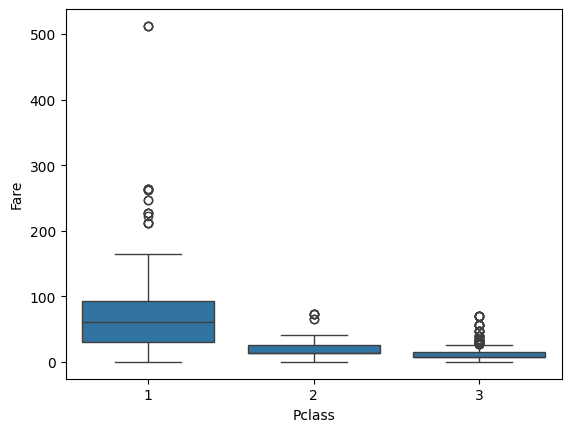

In [10]:
# ３の検証
# FareとPclassの関係性を見る
sns.boxplot(data=train, x='Pclass', y='Fare')

やはり、料金を高く払っている人はクラスも高い

<Axes: xlabel='FareBin', ylabel='Survived'>

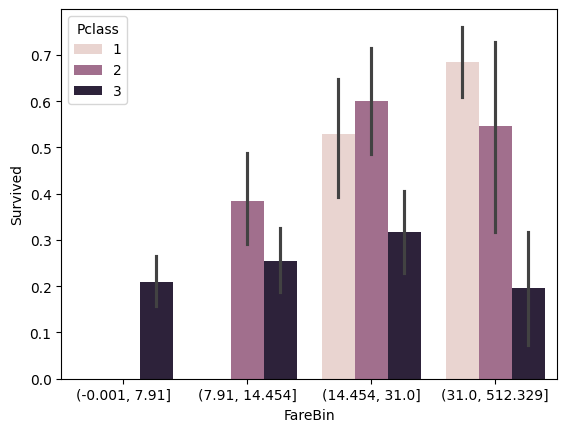

In [11]:
# Fareを4分割にしてみる
train['FareBin'] = pd.qcut(train['Fare'],4)
sns.barplot(data=train, x='FareBin', y='Survived', hue='Pclass')

<Axes: xlabel='AgeBin', ylabel='Survived'>

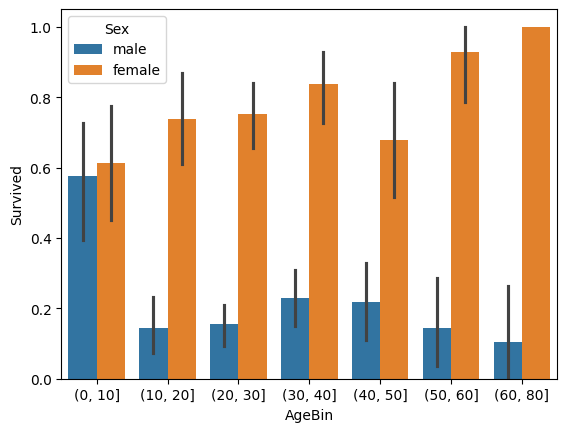

In [12]:
# 20代の中でもやはり男性が多いのか（年代だけでなく性別も含める必要性の検証）
train['AgeBin'] = pd.cut(train['Age'],bins=[0,10,20,30,40,50,60,80])
sns.barplot(data=train, x='AgeBin', y='Survived', hue='Sex')

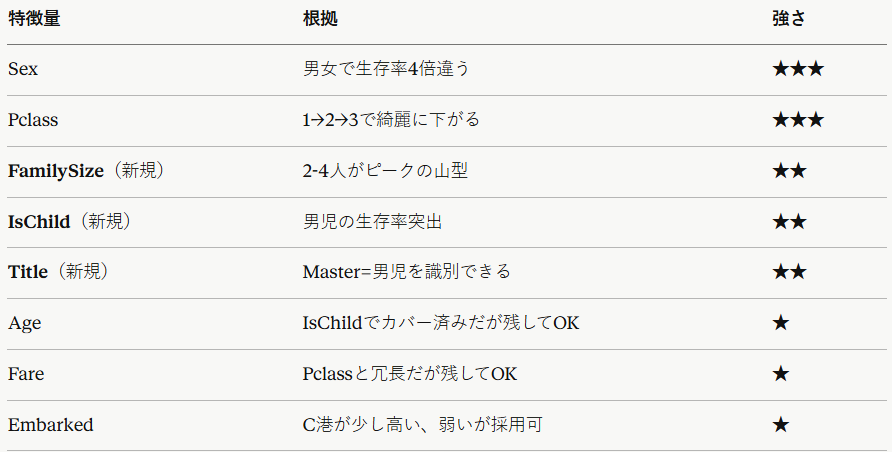

In [13]:
for dataset in [train,test]:
    dataset['Title'] = dataset['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    dataset['Title'] = dataset['Title'].replace(
        ['Dr','Rev','Col','Major','Capt','Sir','Lady','Countess','Don','Jonkheer'], 'Rare'
    )
    dataset['Title'] = dataset['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})
    dataset['Title'] = dataset['Title'].map({'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Rare':4})

    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
    dataset['Isalone'] = (dataset['FamilySize']==1).astype(int)
    dataset['Ischild'] = (dataset['Age'] < 10).astype(int)

    dataset['Sex'] = dataset['Sex'].map({'male':0,'female':1})
    dataset['Embarked'] = dataset['Embarked'].fillna('S')
    dataset['Embarked'] = dataset['Embarked'].map({'S':0,'C':1,'Q':2})

    dataset['Age'] = dataset['Age'].fillna(dataset['Age'].median())
    

features = ['Sex','Pclass','Age','FamilySize','Isalone','Ischild','Fare','Embarked','Title','SibSp','Parch']

X_train = train[features]
y_train = train['Survived']

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print(f'CV平均精度: {scores.mean():.4f} (±{scores.std():.4f})')

CV平均精度: 0.8115 (±0.0274)


## 11ポイント向上！

In [14]:
test['Fare'] = test['Fare'].fillna(test['Fare'].median())
test['Title'] = test['Title'].fillna(4)  # Rareと同じ扱い
print(test[features].isnull().sum())

Sex           0
Pclass        0
Age           0
FamilySize    0
Isalone       0
Ischild       0
Fare          0
Embarked      0
Title         0
SibSp         0
Parch         0
dtype: int64


In [15]:
X_train = train[features]
y_train = train['Survived']
X_test = test[features]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train,y_train)

predictions = model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived':predictions
})

submission.to_csv('submission_v2.csv', index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
